In [1]:
from wavediffusion.wavedata import npyDataResized, npyDataWndHist
from torch.utils.data import DataLoader
import torch
import numpy as np
import os
from torchvision import transforms as tf
from matplotlib import pyplot as plt
import cartopy.crs as ccrs
import torchvision.transforms as tf
from wavediffusion.waveana import add_lat_lon
%load_ext autoreload
%autoreload 2

In [4]:
OPTION = 2
test_file_path = '/global/homes/j/jiarongw/scratch_folder/wave_data/mean_global/'
test_file_names = [('wavemean_200404', 'forcing_200404')]
stats_file = os.path.join(test_file_path, f'stats_OPTION{OPTION}.npz')
stats = np.load(stats_file)
meanx, stdx = stats['meanx'], stats['stdx']
meanf, stdf = stats['meanf'], stats['stdf']

### Construct test dataset
test_file_list = [(os.path.join(test_file_path, f'{x}.npy'), 
                   os.path.join(test_file_path, f'{f}.npy')) for x, f in test_file_names]
test = npyDataResized(
    test_file_list,
    resize_x=(320,320), resize_f=(320,320), 
    landmaskname=os.path.join(test_file_path, 'mask.npy'),
    use_icymask=True,
    compute_stats=False,
    meanx=meanx, stdx=stdx, meanf=meanf, stdf=stdf,
    OPTION=OPTION
)

In [5]:
x, f, icymask = test.__getitem__(0)
x0 = test.invert_x(x)
f0 = test.invert_f(f)

In [6]:
# ds = add_lat_lon (np.concatenate([x0,f0], axis=0), ['hs','tm','thetam','u','v','dpt','ifa'])
ds = add_lat_lon (np.concatenate([x0,f0], axis=0), ['hs','uss','vss','mssu','mssc','u','v','dpt','ifa'])

### With colorbar and title

Text(0.5, 1.0, 'Mean wave direction')

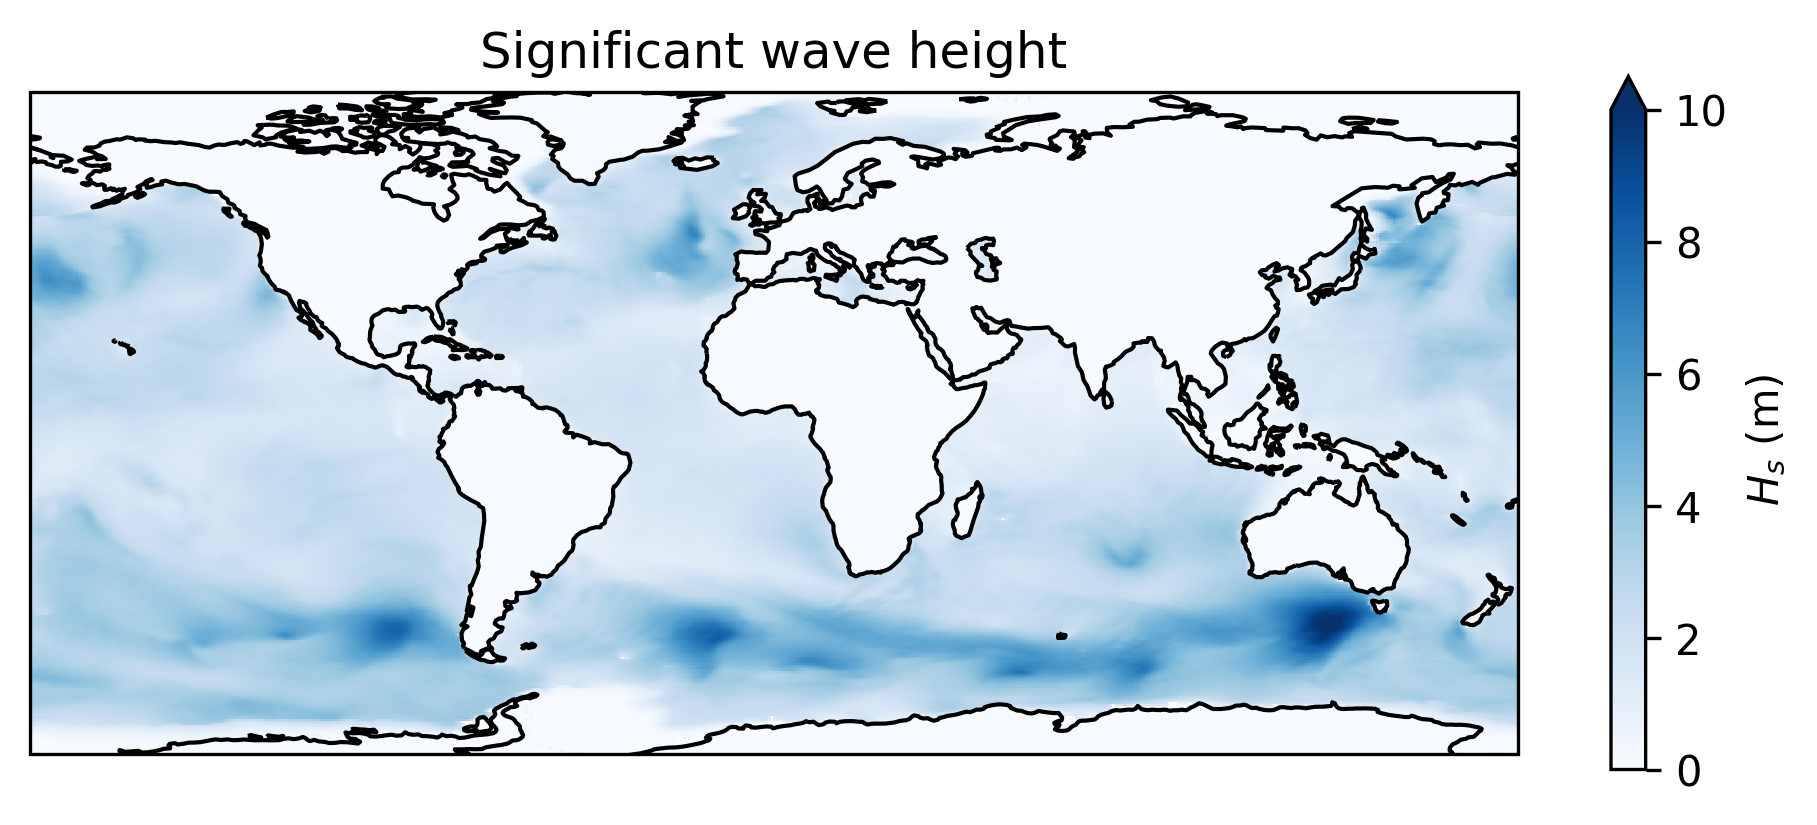

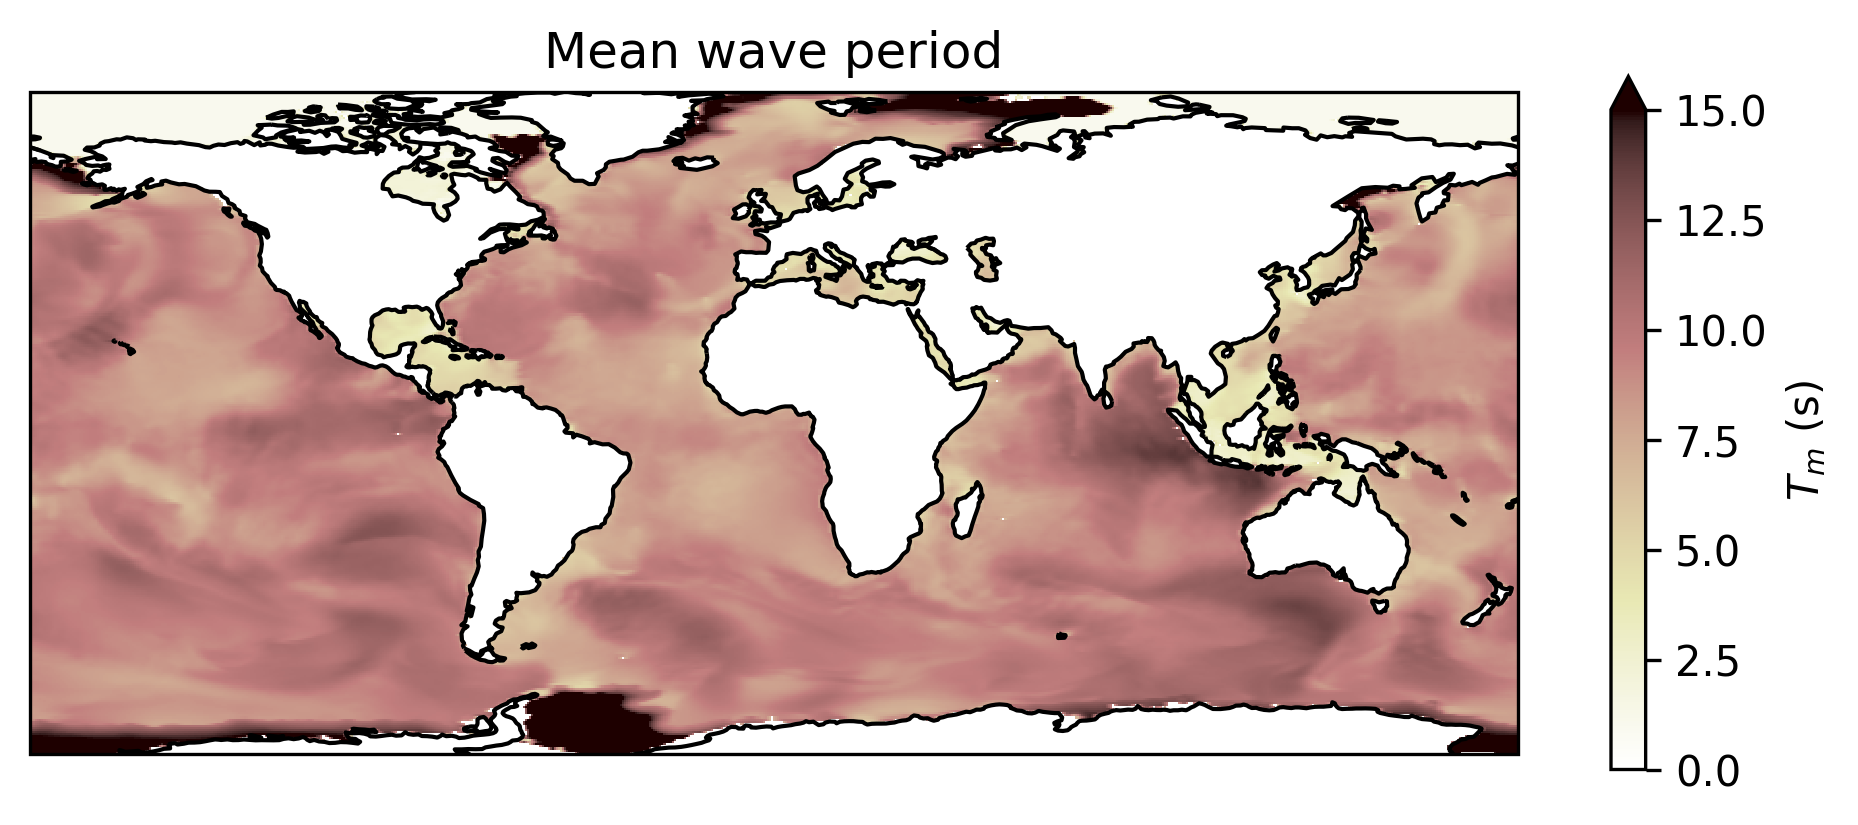

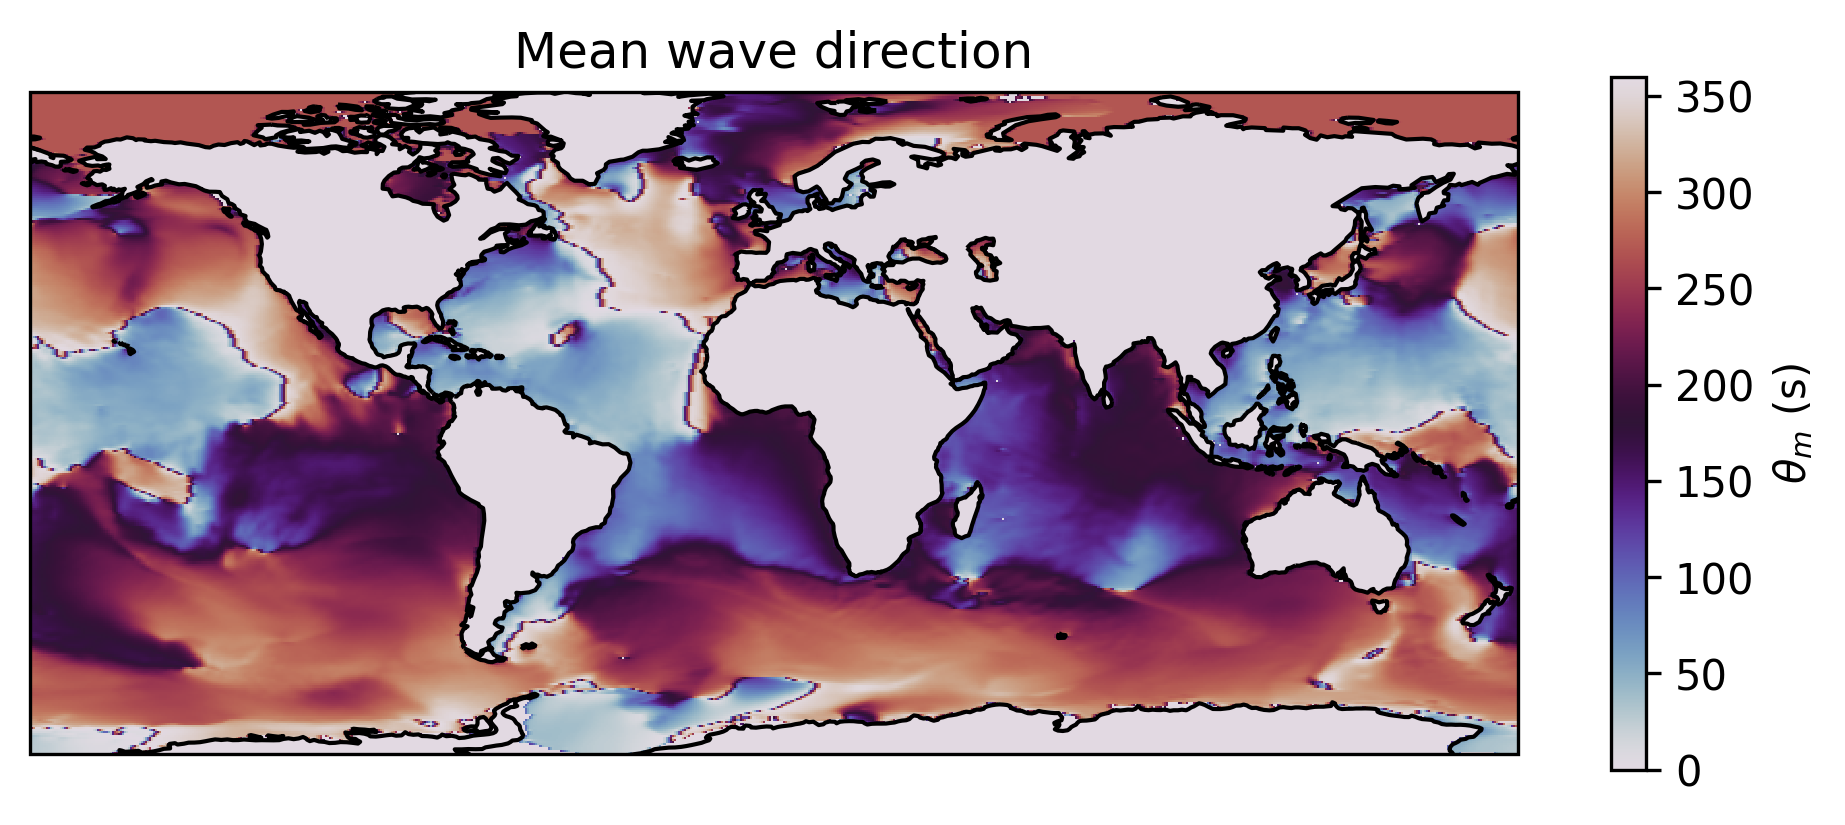

In [48]:
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=[8,3], dpi=300)
ds.hs.plot(ax=ax, vmax=10, vmin=0, cmap='Blues', transform=ccrs.PlateCarree(), 
           cbar_kwargs={'label':'$H_s$ (m)'})
ax.coastlines()
plt.title('Significant wave height')

fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=[8,3], dpi=300)
ds.tm.plot(ax=ax, vmax=15, vmin=0, cmap='pink_r', transform=ccrs.PlateCarree(), 
           cbar_kwargs={'label':'$T_m$ (s)'})
ax.coastlines()
plt.title('Mean wave period')

fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=[8,3], dpi=300)
ds.thetam.plot(ax=ax, vmax=360, vmin=0, cmap='twilight', transform=ccrs.PlateCarree(), 
           cbar_kwargs={'label':r'$\theta_m$ (s)'})
ax.coastlines()
plt.title('Mean wave direction')

Text(0.5, 1.0, 'Mean Square Slope (Crosswave)')

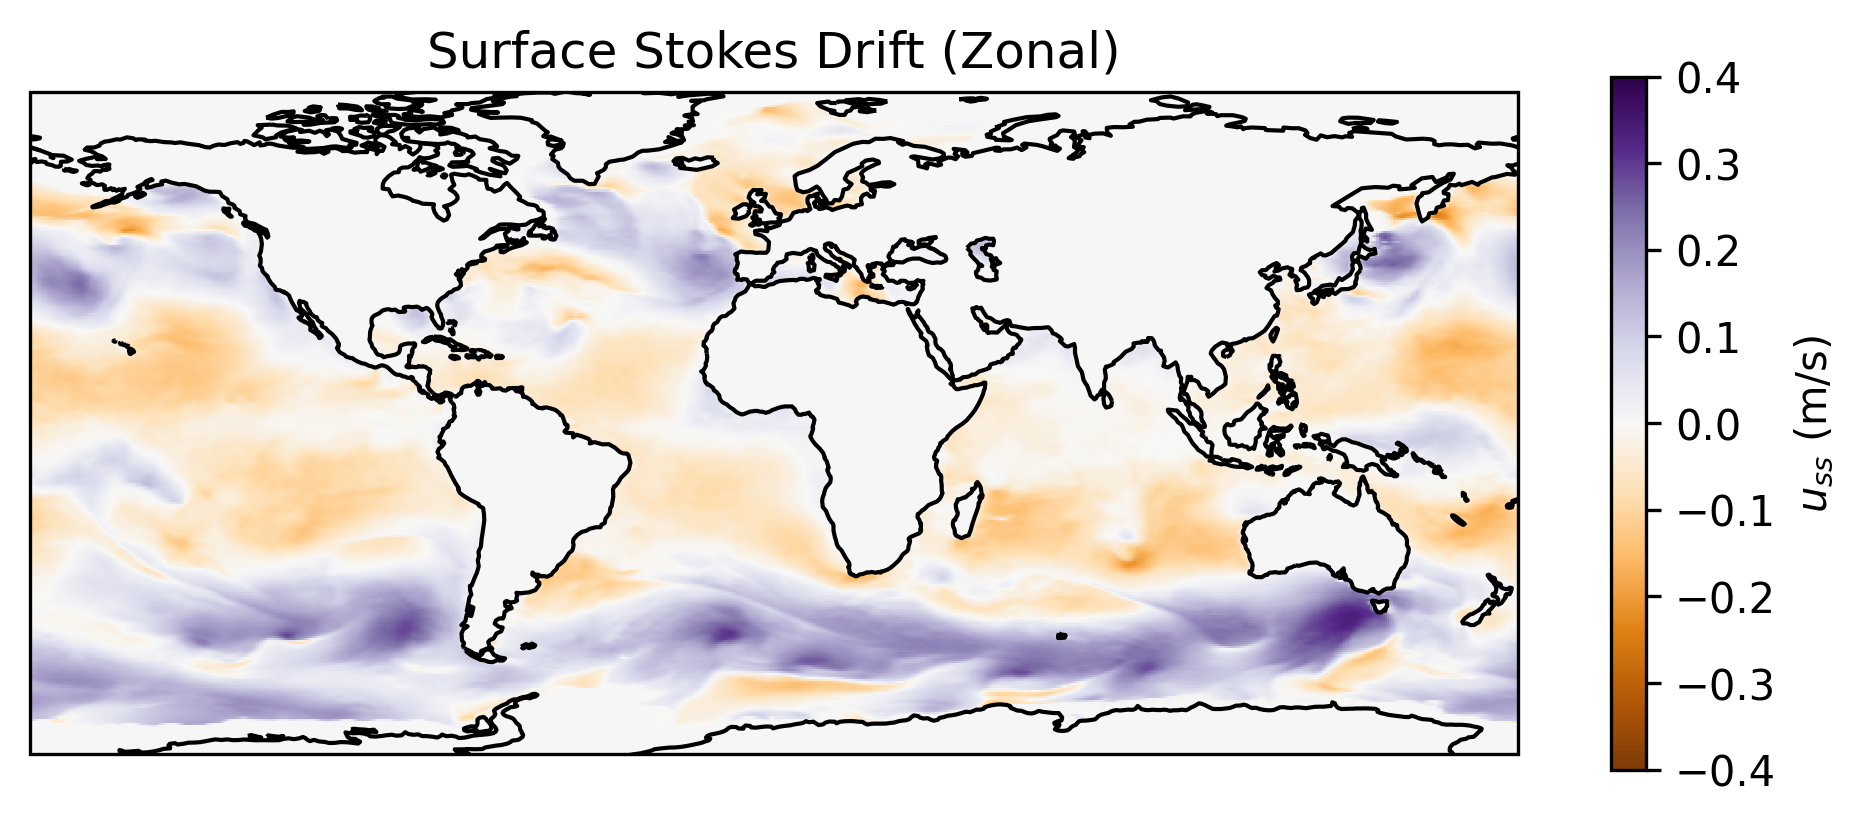

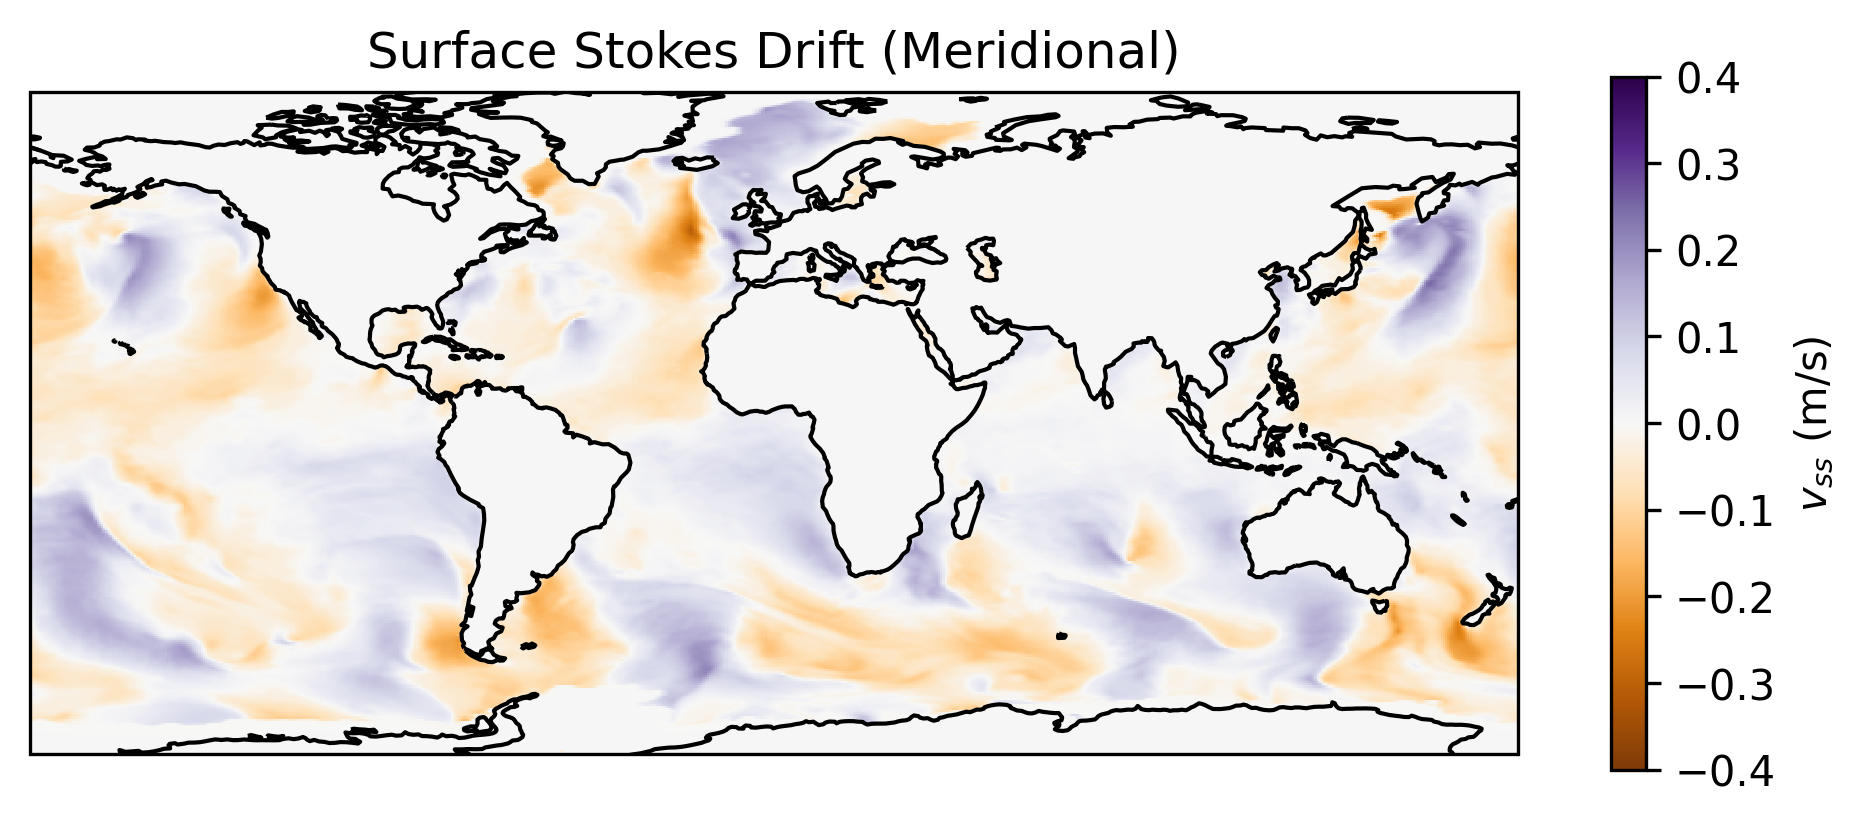

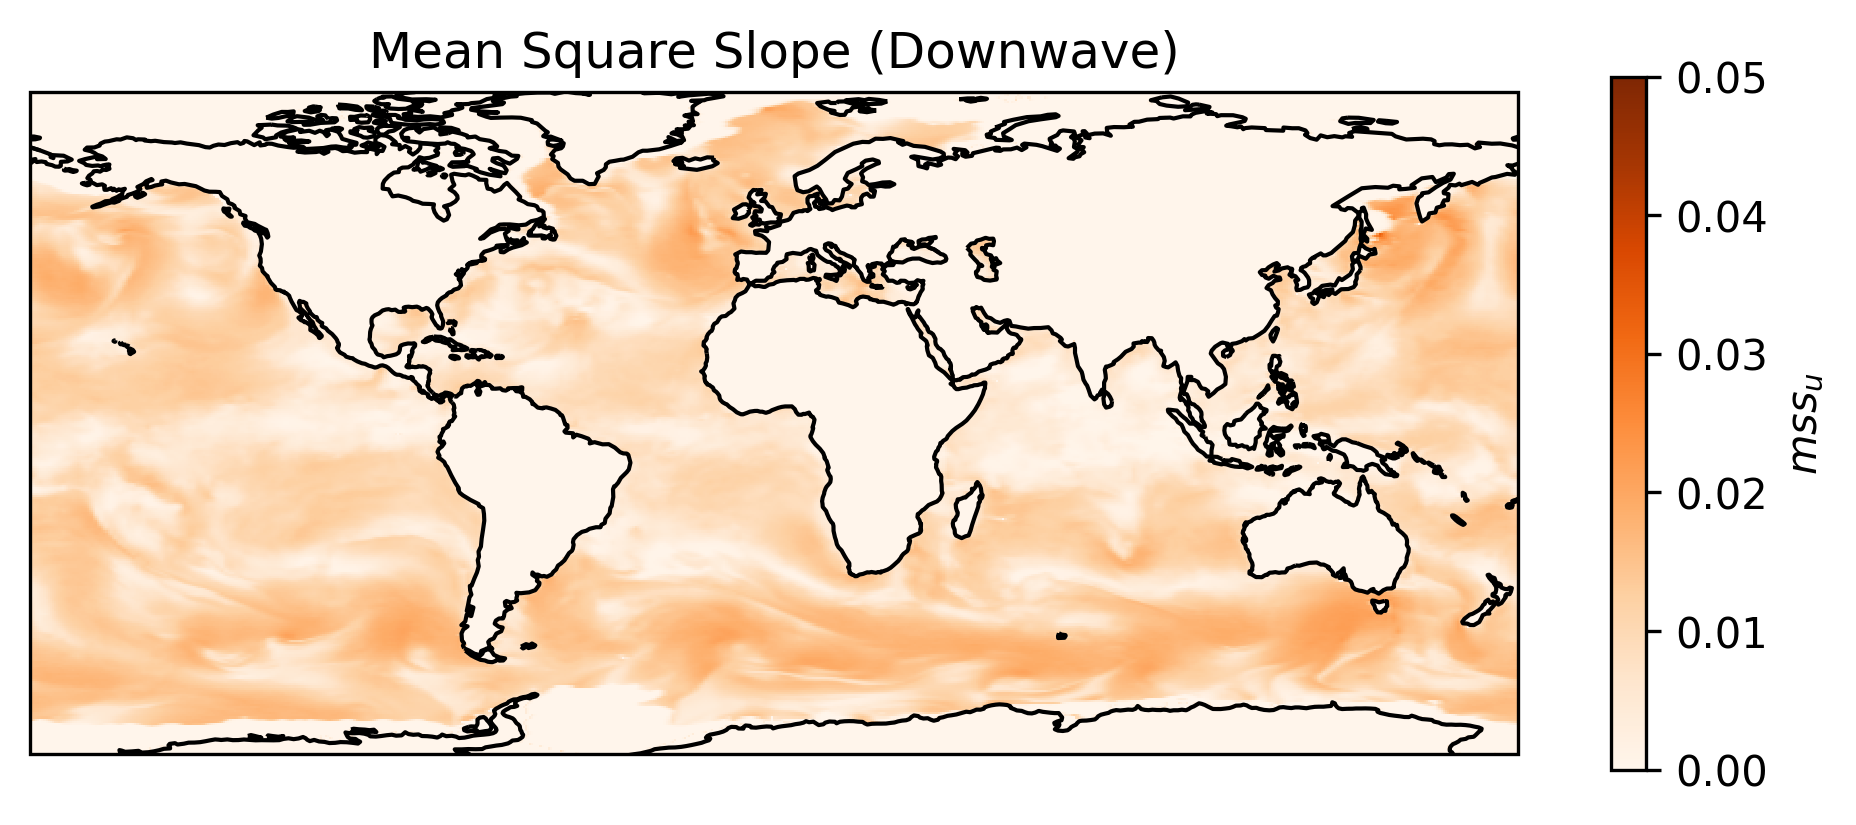

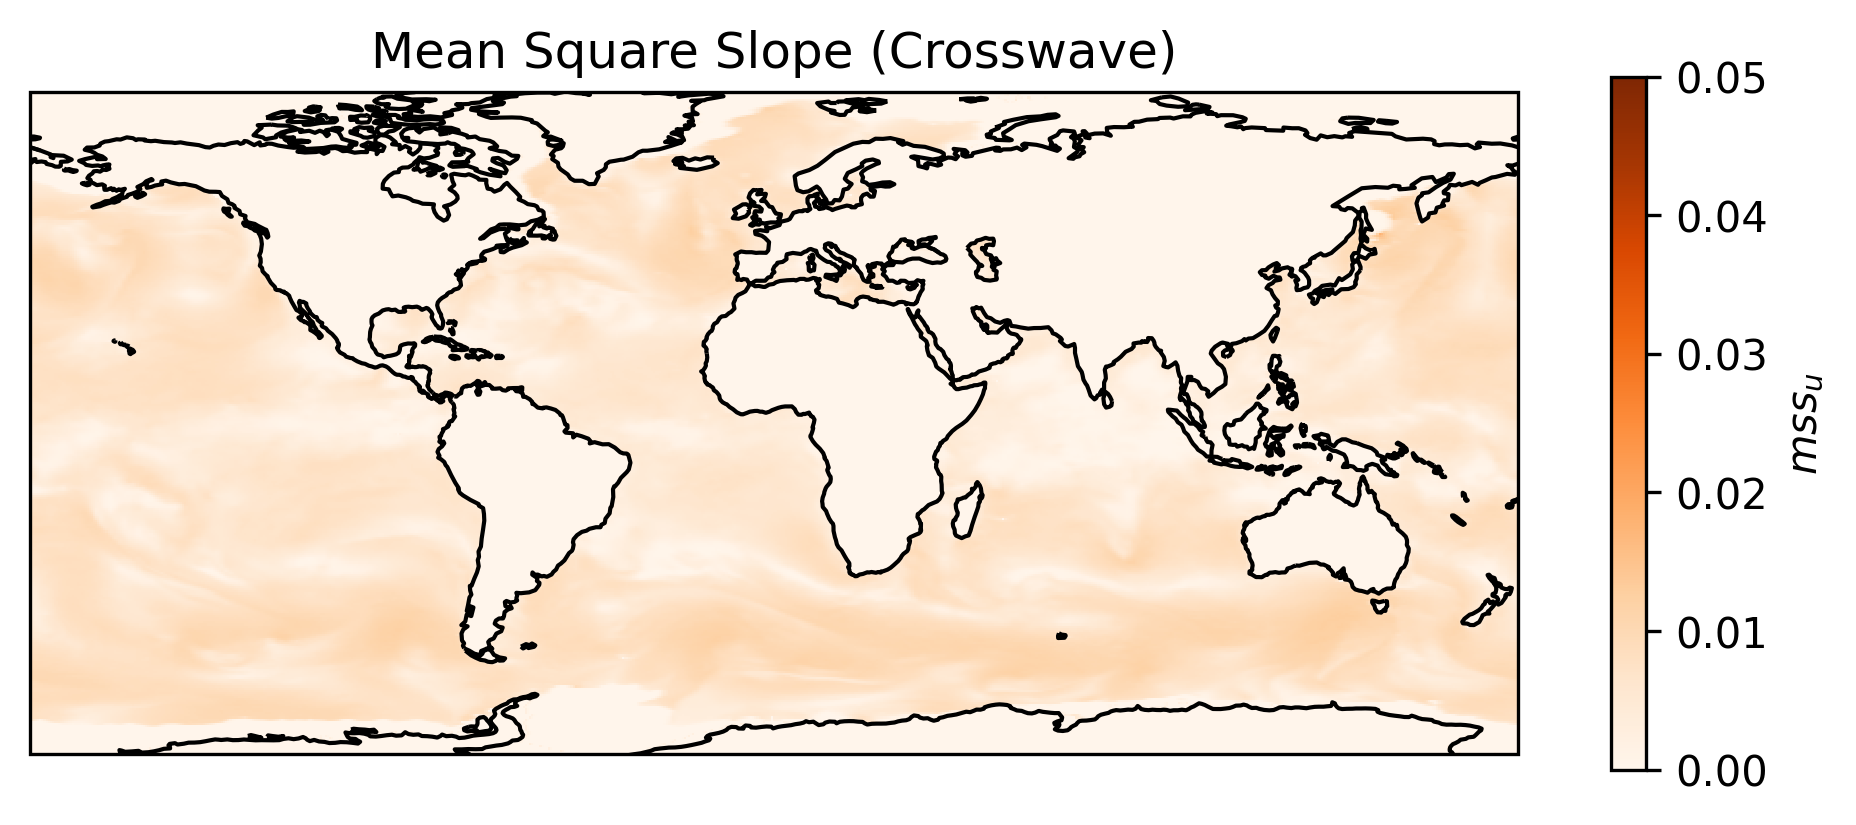

In [13]:
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=[8,3], dpi=300)
ds.uss.plot(ax=ax, vmax=0.4, vmin=-0.4, cmap='PuOr', transform=ccrs.PlateCarree(), 
           cbar_kwargs={'label':'$u_{ss}$ (m/s)'})
ax.coastlines()
plt.title('Surface Stokes Drift (Zonal)')

fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=[8,3], dpi=300)
ds.vss.plot(ax=ax, vmax=0.4, vmin=-0.4, cmap='PuOr', transform=ccrs.PlateCarree(), 
           cbar_kwargs={'label':'$v_{ss}$ (m/s)'})
ax.coastlines()
plt.title('Surface Stokes Drift (Meridional)')

fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=[8,3], dpi=300)
ds.mssu.plot(ax=ax, vmax=0.05, vmin=0, cmap='Oranges', transform=ccrs.PlateCarree(), 
           cbar_kwargs={'label':'$mss_u$'})
ax.coastlines()
plt.title('Mean Square Slope (Downwave)')
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=[8,3], dpi=300)
ds.mssc.plot(ax=ax, vmax=0.05, vmin=0, cmap='Oranges', transform=ccrs.PlateCarree(), 
           cbar_kwargs={'label':'$mss_u$'})
ax.coastlines()
plt.title('Mean Square Slope (Crosswave)')

### Without 

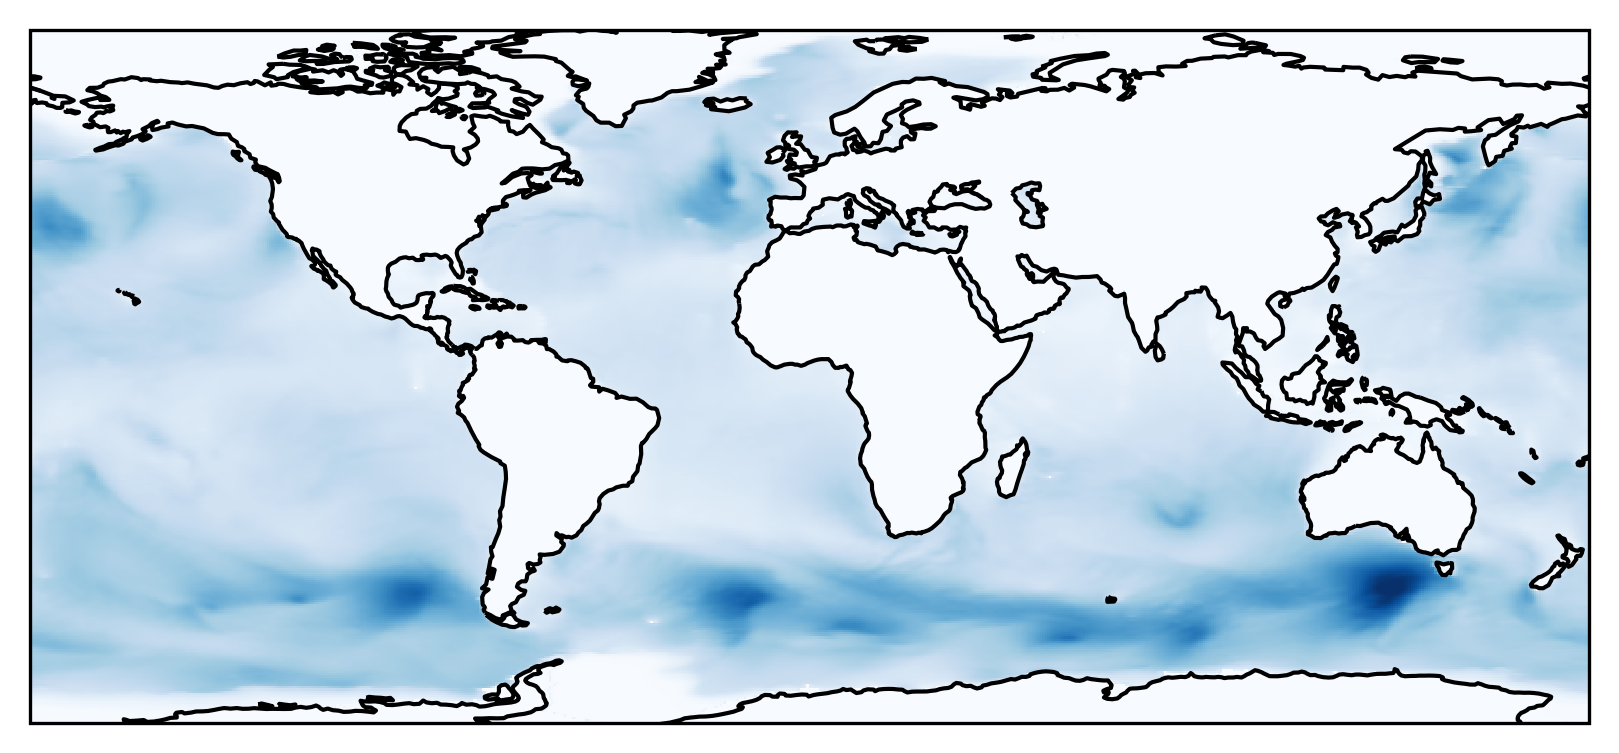

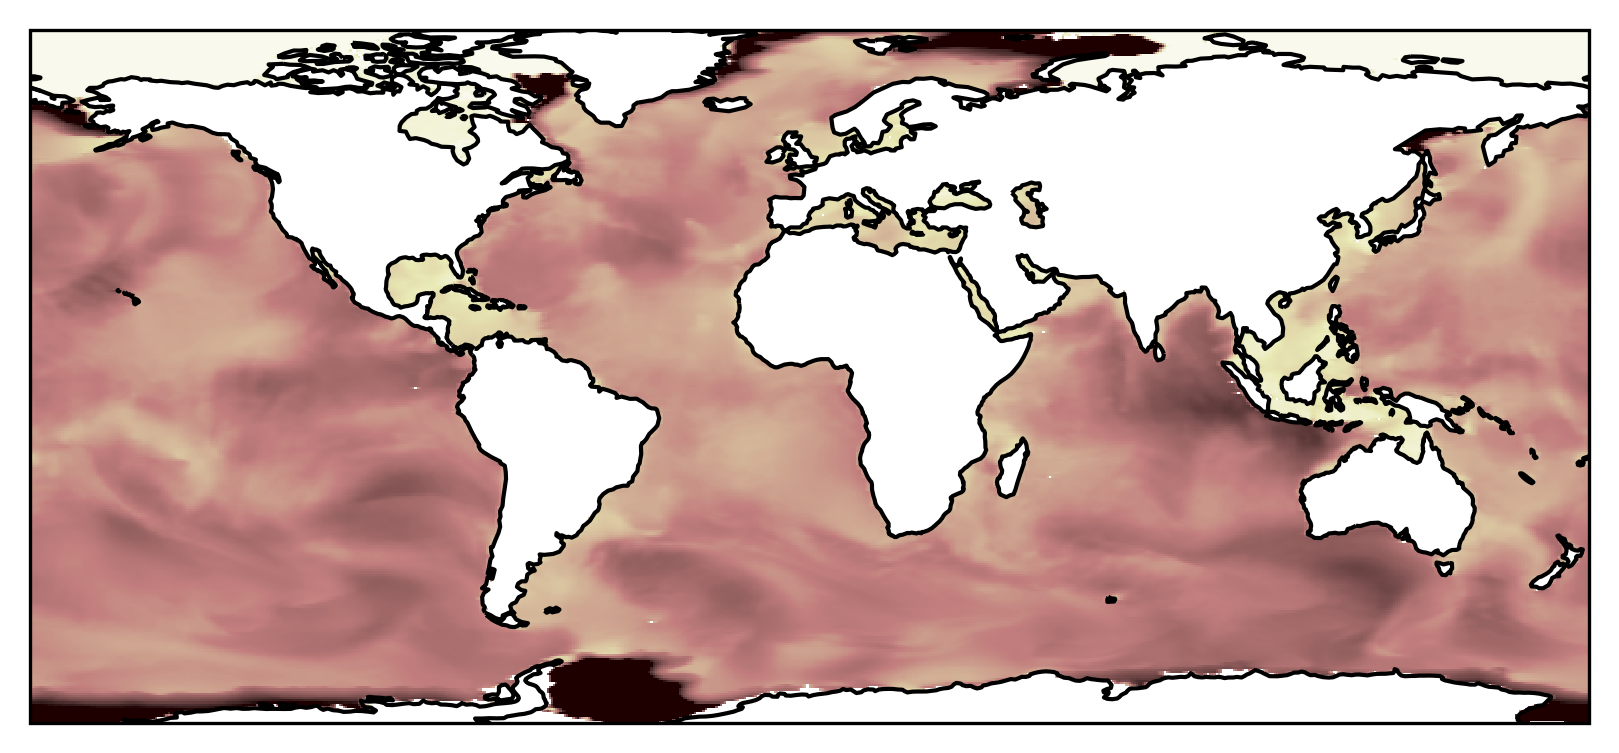

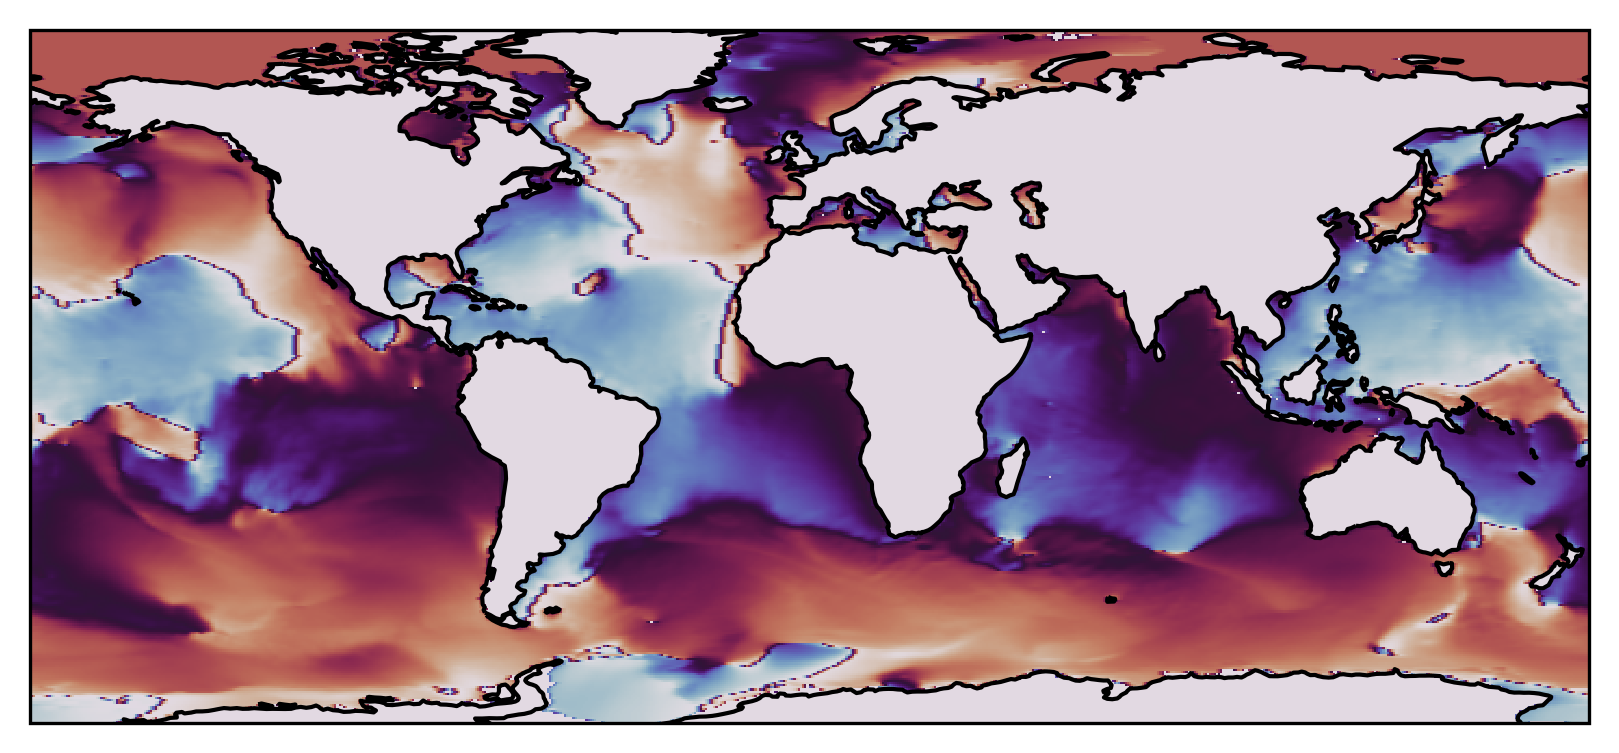

In [49]:
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=[8,3], dpi=300)
ds.hs.plot(ax=ax, vmax=10, vmin=0, cmap='Blues', transform=ccrs.PlateCarree(), add_colorbar=False)
ax.coastlines()

fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=[8,3], dpi=300)
ds.tm.plot(ax=ax, vmax=15, vmin=0, cmap='pink_r', transform=ccrs.PlateCarree(), add_colorbar=False)
ax.coastlines()

fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=[8,3], dpi=300)
ds.thetam.plot(ax=ax, vmax=360, vmin=0, cmap='twilight', transform=ccrs.PlateCarree(), add_colorbar=False)
ax.coastlines()

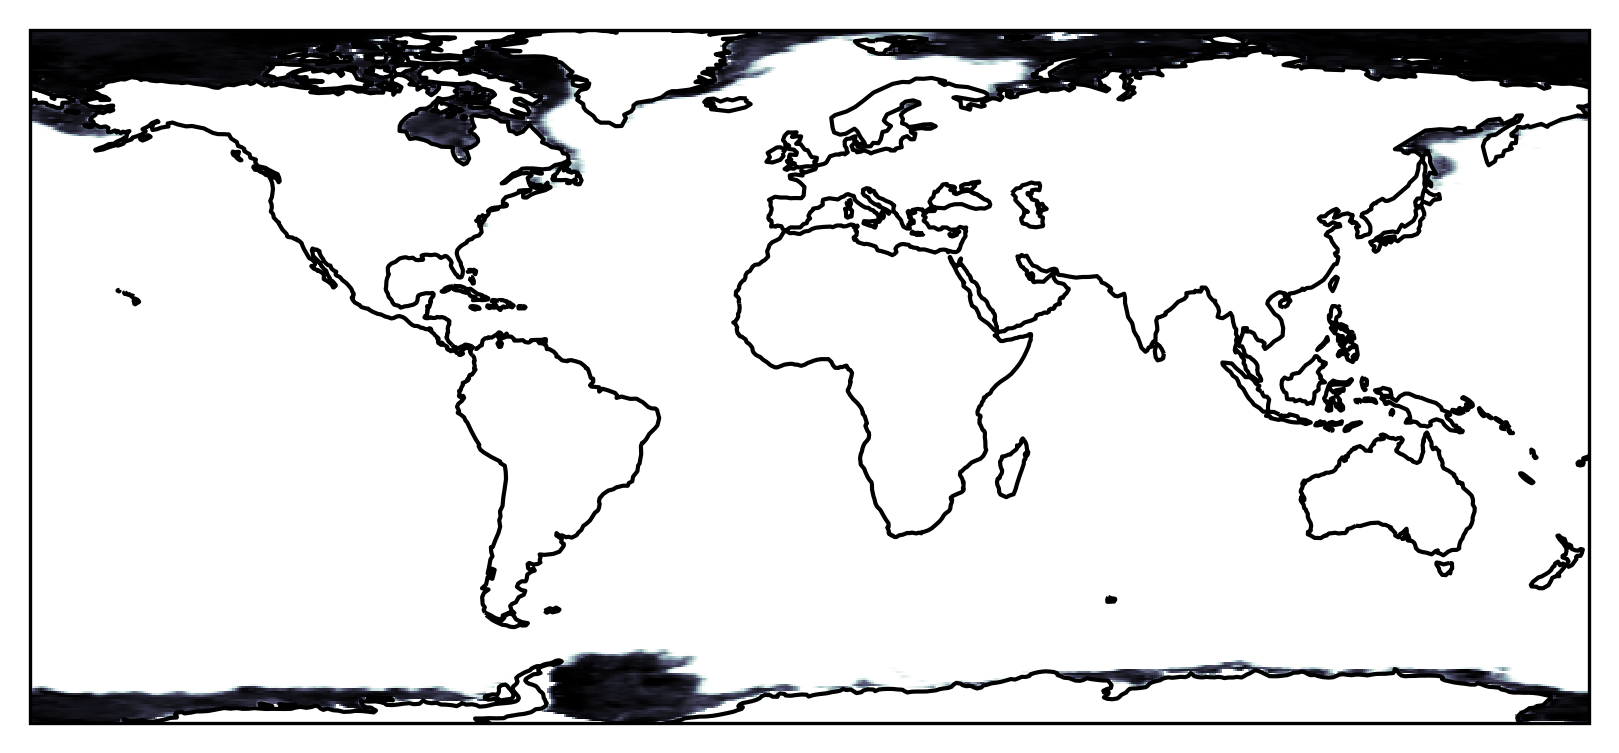

In [53]:
# fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=[8,3], dpi=300)
# ds.dpt.plot(ax=ax, vmax=8000, vmin=0, cmap='Grays', transform=ccrs.PlateCarree(), add_colorbar=False)
# ax.coastlines()

fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=[8,3], dpi=300)
ds.ifa.plot(ax=ax, vmax=1, vmin=0, cmap='bone_r', transform=ccrs.PlateCarree(), add_colorbar=False)
ax.coastlines()

In [3]:
test = npyDataWndHist(
    test_file_list,
    resize_x=(320,320), resize_f=(320,320), 
    landmaskname=os.path.join(test_file_path, 'mask.npy'),
    use_icymask=True,
    compute_stats=False,
    meanx=meanx, stdx=stdx, meanf=meanf, stdf=stdf,
    OPTION=1
)

In [4]:
x, f, icymask = test.__getitem__(0)
x0 = test.invert_x(x)
f0 = test.invert_f(f)
icymask0 = tf.Resize((320,720))(icymask)
ds = add_lat_lon (np.concatenate([x0,f0[:4],icymask0], axis=0), ['hs','tm','thetam','u','v','dpt','ifa','mask'])

/global/u1/j/jiarongw/wavediffusion/src/wavediffusion/wavedata.py:458: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /mscratch/sd/s/swowner/pytorch-build/pytorch/2.6.0/pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  f_hist = torch.from_numpy(self.F_files[file_idx_hist][local_idx_hist]).float()


In [13]:
f[4].mean()

tensor(0.0468)

In [7]:
test.stdf

tensor([6.5479e+00, 5.3855e+00, 1.5824e+03, 1.0000e+00, 6.5479e+00, 5.3855e+00,
        6.5479e+00, 5.3855e+00, 6.5479e+00, 5.3855e+00, 6.5479e+00, 5.3855e+00,
        6.5479e+00, 5.3855e+00])

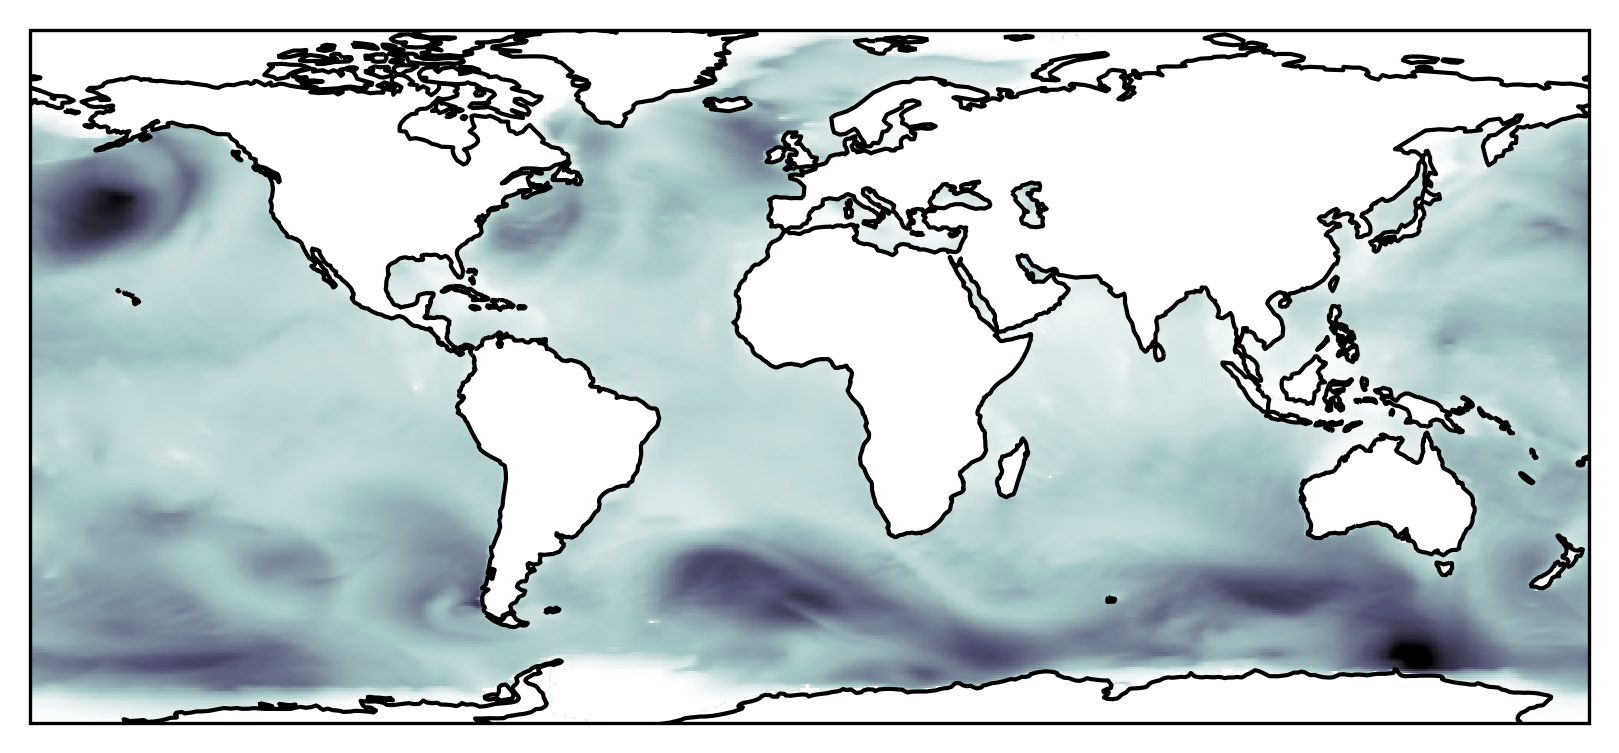

In [15]:
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=[8,3], dpi=300)
ds.hs.plot(ax=ax, vmax=10, vmin=0, cmap='bone_r', transform=ccrs.PlateCarree(), add_colorbar=False)
ax.coastlines()